In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import yfinance as yf
from talib import RSI, BBANDS, MACD

In [3]:
sns.set_style('whitegrid')
idx = pd.IndexSlice

In [7]:
ticker = "4DX.AX"
df = yf.download(ticker, start="2026-01-01", end="2026-08-01")
df["Close"]

[*********************100%***********************]  1 of 1 completed


Ticker,4DX.AX
Date,
2026-01-02,4.54
2026-01-05,4.08
2026-01-06,4.19
2026-01-07,4.69
2026-01-08,4.60
...,...
2026-07-27,3.28
2026-07-28,3.25
2026-07-29,3.26


In [23]:
data = df['Close'][ticker].to_numpy()
up, mid, low = BBANDS(data, timeperiod=21, nbdevup=2, nbdevdn=2, matype=0)

In [24]:
rsi = RSI(data, timeperiod=14)

In [25]:
macd, macdsignal, macdhist = MACD(df['Close'][ticker].to_numpy(), fastperiod=12, slowperiod=26, signalperiod=9)

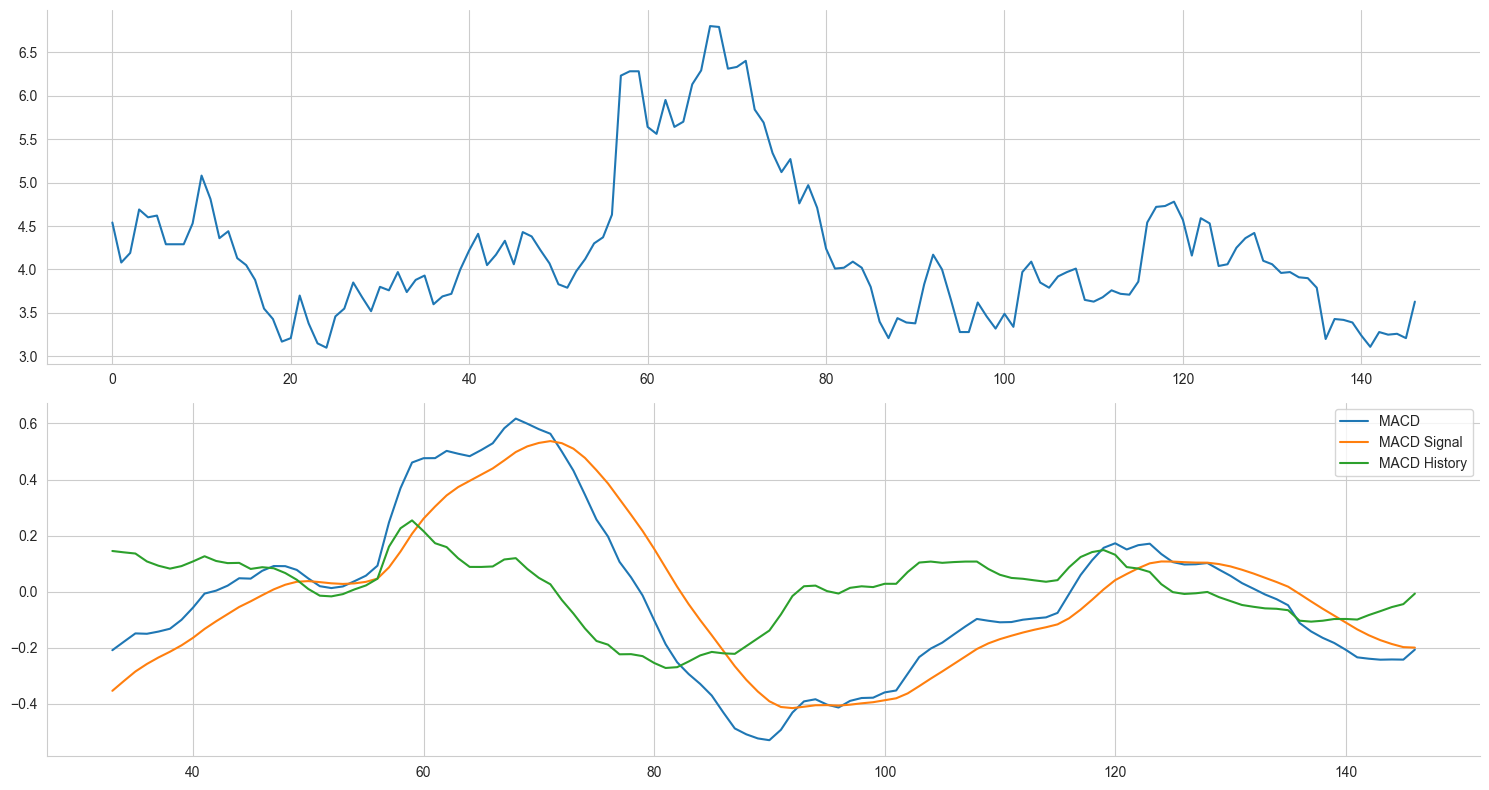

In [26]:
macd_data = pd.DataFrame({ticker: data,'MACD': macd, 'MACD Signal': macdsignal, 'MACD History': macdhist})

fig, axes= plt.subplots(nrows=2, figsize=(15, 8))
macd_data[ticker].plot(ax=axes[0])
macd_data.drop(ticker, axis=1).plot(ax=axes[1])
fig.tight_layout()
sns.despine()

In [27]:
data = pd.DataFrame({ticker: data, 'BB Up': up, 'BB Mid': mid, 'BB down': low, 'RSI': rsi, 'MACD': macd})

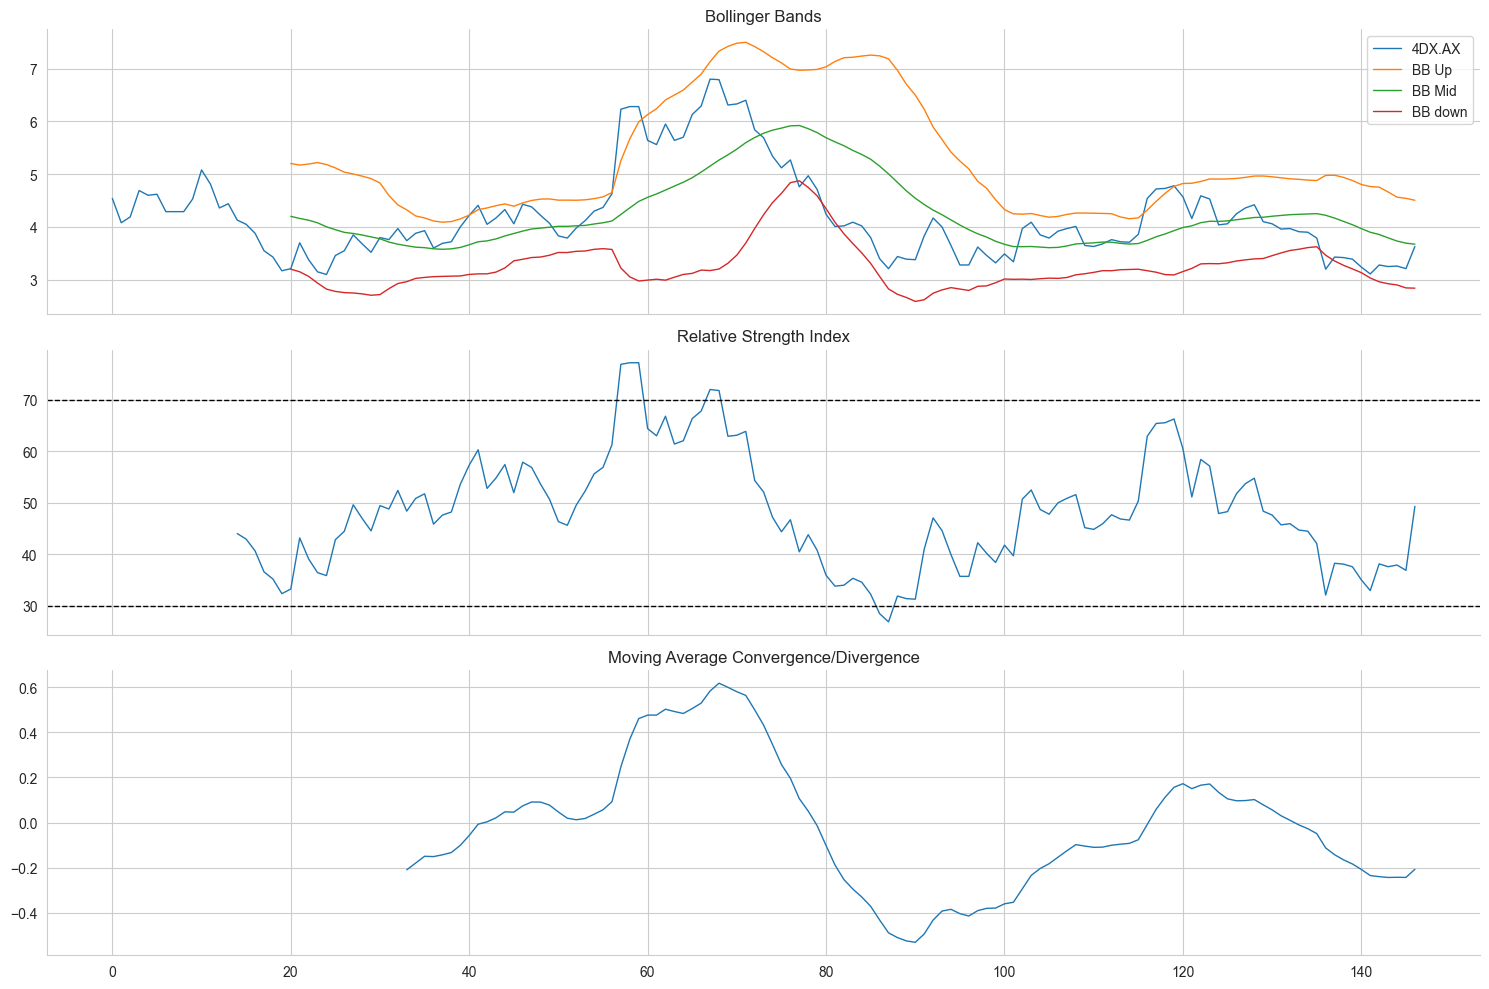

In [28]:
fig, axes= plt.subplots(nrows=3, figsize=(15, 10), sharex=True)
data.drop(['RSI', 'MACD'], axis=1).plot(ax=axes[0], lw=1, title='Bollinger Bands')
data['RSI'].plot(ax=axes[1], lw=1, title='Relative Strength Index')
axes[1].axhline(70, lw=1, ls='--', c='k')
axes[1].axhline(30, lw=1, ls='--', c='k')
data.MACD.plot(ax=axes[2], lw=1, title='Moving Average Convergence/Divergence', rot=0)
axes[2].set_xlabel('')
fig.tight_layout()
sns.despine();